# DeepSeek R-1 (0528 update)

Let's take a moment to examine these new DeepSeek R-1 models.  You can read about the creation of these R-1 models in this paper [DeepSeek-R1: Incentivizing Reasoning Capability in LLMs via
Reinforcement Learning](https://arxiv.org/pdf/2501.12948).

DeepSeek has developed a new methodology that allow them to take their v3-base model and to make it behave like a "reasoning" model.  This means that the model is encouraged to reveal many thoughts which it can then consider as it arrives at its final answer.

From their paper, here's the prompt they use to train the model.

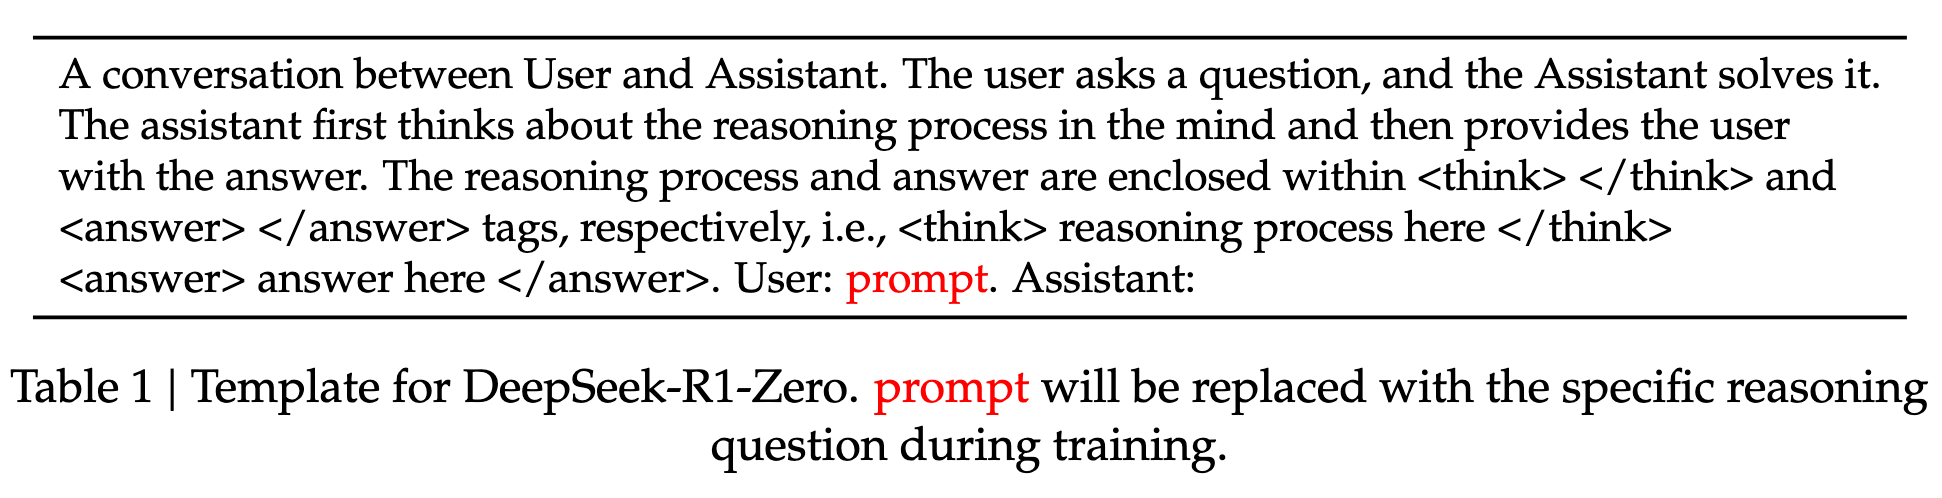

They use [two reward models for their RL with GPRO](https://arxiv.org/pdf/2501.12948), one for accuracy (answer quality) and one for format (inclusion of thoughts before answer)

You can access the model(s) via [the web](https://chat.deepseek.com/sign_in), via [an app you can run](https://apps.apple.com/us/app/deepseek-ai-assistant) on your phone, or all of the models have been released on [Hugging Face](https://huggingface.co/collections/deepseek-ai/deepseek-r1-678e1e131c0169c0bc89728d).  Let's try the one built on top of Qwen3 8B.

For contrast, let's start with trying an OpenAI lower end model first.  We're trying to see if there are questions those lower end ChapGPT models cannot answer but the DeepSeek model can.

<a id = 'openai'></a>

## Open AI

OpenAI is the creator of ChatGPT.  In order to use it programatically you must have an API key which requires a paid account.  You should never put your API key directly into the notebook.  Google offers the ability to attach secrets to your Colab notebooks.  This cell assumes you have added your API key as a secret in Colab.

In [ ]:
#install the api library
!pip install -q openai

In [ ]:
#Access your api key.  I've stored mine as a secret in Colab.
import os
import time
from google.colab import userdata
OPENAI_API_KEY = userdata.get('OPEN_AI_KEY')
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

In [ ]:
from openai import OpenAI
client = OpenAI()

response = client.chat.completions.create(
  model="gpt-4o",
  messages=[
    {"role": "system", "content": "You are a clever reasoner."},
    {"role": "user", "content": "How many r's in raspberry?"},
  ]
)

print(response.choices[0].message.content)

There are two 'r's in the word "raspberry."


## DeepSeek R-1 Qwen3 8B

Their model is built on top of the Mixture of Experts v3 model that has a total of 671B paramters of which only 37B are activated for a prediction.  In addition to their larger model, DeepSeek created a series of distilled 1.5B, 7B, 8B, 14B, 32B, and 70B checkpoints based on Qwen2.5 and Llama3 models.  They updated both the larger model and the distilled one using Qwen3 8B. Let's try the one based on Qwen3 8B.  We'll also quantize the model to reduce the size of its GPU memory.

In [1]:
!pip install -q -U bitsandbytes flash_attn

In [2]:
from pprint import pprint

In [3]:
import torch
from transformers import BitsAndBytesConfig

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

In [4]:
# Use a pipeline as a high-level helper
from transformers import pipeline

messages = [
    {"role": "user", "content": "How many r's in raspberry?"},
]

#This will load the FULL 8B paramater model WITHOUT quantization ~ 14.4 of 15.0GB GPU RAM and 25 minutes to respond
#pipe = pipeline("text-generation", model="deepseek-ai/DeepSeek-R1-0528-Qwen3-8B", model_kwargs={"torch_dtype": torch.bfloat16,},
#    device_map="auto",)

# uncomment the following to run with quantization ~ 7.0 of 15.0GB and 3 minutes to respond
pipe = pipeline("text-generation", model="deepseek-ai/DeepSeek-R1-0528-Qwen3-8B", model_kwargs={"torch_dtype": torch.bfloat16, "quantization_config": quantization_config},
    device_map="auto",)

outputs = pipe(messages, max_new_tokens=2048,)


pprint(outputs[0]["generated_text"][-1], compact=True)

Unrecognized keys in `rope_scaling` for 'rope_type'='yarn': {'attn_factor'}
Unrecognized keys in `rope_scaling` for 'rope_type'='yarn': {'attn_factor'}


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda:0


{'content': '<think>\n'
            'First, the question is: "How many r\'s in raspberry?" I need to '
            "count the number of times the letter 'r' appears in the word "
            '"raspberry".\n'
            '\n'
            'Let me spell out "raspberry": R-A-S-P-B-E-R-R-Y.\n'
            '\n'
            "Now, I'll go through each letter:\n"
            '\n'
            "- Position 1: R – that's one 'r'.\n"
            '\n'
            "- Position 2: A – not 'r'.\n"
            '\n'
            "- Position 3: S – not 'r'.\n"
            '\n'
            "- Position 4: P – not 'r'.\n"
            '\n'
            "- Position 5: B – not 'r'.\n"
            '\n'
            "- Position 6: E – not 'r'.\n"
            '\n'
            "- Position 7: R – that's another 'r'.\n"
            '\n'
            "- Position 8: R – and yet another 'r'.\n"
            '\n'
            "- Position 9: Y – not 'r'.\n"
            '\n'
            "So, from this, I see 'r' at positions 1, 7,

In [5]:
#let's try a second example
messages = [
    {"role": "user", "content": "How many i's in mississippi?"},
]

outputs = pipe(messages, max_new_tokens=1024,)


pprint(outputs[0]["generated_text"][-1], compact=True)

{'content': '<think>\n'
            'First, the question is: "How many i\'s in mississippi?" I need to '
            "count the number of times the letter 'i' appears in the word "
            '"mississippi".\n'
            '\n'
            'Let me write down the word: M-I-S-S-I-S-S-I-P-P-I.\n'
            '\n'
            "Now, I'll go through each letter and count the 'i's.\n"
            '\n'
            'Starting from the beginning:\n'
            '\n'
            "- M: not an 'i'\n"
            '\n'
            "- I: this is an 'i', so count = 1\n"
            '\n'
            "- S: not an 'i'\n"
            '\n'
            "- S: not an 'i'\n"
            '\n'
            "- I: this is another 'i', so count = 2\n"
            '\n'
            "- S: not an 'i'\n"
            '\n'
            "- S: not an 'i'\n"
            '\n'
            "- I: this is a third 'i', so count = 3\n"
            '\n'
            "- P: not an 'i'\n"
            '\n'
            "- P: not an 'i'\n"
  

In [ ]:
#Is the model designed to avoid anti-Chinese predictions? Will it acknowledge the competing claims?
#Depends on where model is being run?
prompt = "Tell me about the Spratly Islands in the South China Sea"

messages = [
    {"role": "user", "content": prompt},
]

outputs = pipe(messages, max_new_tokens=1024,)


pprint(outputs[0]["generated_text"][-1], compact=True)

{'content': '<think>\n'
            'Okay, so I need to tell about the Spratly Islands in the South '
            "China Sea. Hmm, where do I start? I remember they're a group of "
            "islands, but I'm not exactly sure about their location or how "
            "many there are. I think they're near the Philippines, maybe? I've "
            "heard they're contested, so different countries claim them. I "
            'believe China has a significant presence there, maybe with some '
            "islands built up. There's also Taiwan involved, right? I'm a bit "
            'fuzzy on the details though.\n'
            '\n'
            "Wait, how many islands are there? I think it's over 100, but I'm "
            "not certain. Maybe 200? I should check that. Oh, but I can't "
            "access the internet, so I'll have to go with what I remember. I "
            "think it's around 200 islets, reefs, and rocks. They're spread "
            'out over a large area, maybe 600 naut

In [ ]:
#Use this cell to try your own questions or prompts
prompt = ""

messages = [
    {"role": "user", "content": prompt},
]

outputs = pipe(messages, max_new_tokens=1024,)


pprint(outputs[0]["generated_text"][-1], compact=True)

In [ ]:
#Use this cell to try your own questions or prompts
prompt = ""

messages = [
    {"role": "user", "content": prompt},
]

outputs = pipe(messages, max_new_tokens=1024,)


pprint(outputs[0]["generated_text"][-1], compact=True)